# Multi-Class Classification with Hybrid Balancing (SMOTE + Undersampling)
This notebook implements a robust machine learning pipeline for SDN traffic classification.

### Hybrid Balancing Strategy:
To ensure the model learns effectively from all 7 classes, we enforce a target of **1,000 samples per class** in the training set:
1.  **Split-First**: Data is split into Stratified Training and Testing sets.
2.  **Majority Classes (>1000)**: We use **Random Undersampling** to downsample these to 1,000.
3.  **Minority Classes (<1000)**: We use **SMOTE (Synthetic Minority Over-sampling Technique)** to generate synthetic samples up to 1,000.
4.  **Scaling and Training**: Models are trained on this perfectly balanced set (7,000 samples total per split) and evaluated on the original (imbalanced) test distribution.

### Visualizations:
- Confusion Matrices for each model.
- Performance comparison plots (Accuracy, F1, Kappa, ROC AUC).


In [8]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             roc_auc_score, cohen_kappa_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC 
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy.special import softmax

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [9]:
df = pd.read_csv("preprocessed_data.csv")
X = df.drop("Category", axis=1)
y_multi = df["Category"]

print("Classes Count:\n", y_multi.value_counts())

Classes Count:
 Category
2    164974
0     53551
6      1487
5      1133
3       305
1        91
4        23
Name: count, dtype: int64


In [10]:
# Base Model Definitions
models = {
    "SVM": LinearSVC(dual=False, random_state=42, max_iter=10000),
    "DT": DecisionTreeClassifier(random_state=42, max_depth=20),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42, tree_method="hist")
}

# Add Hybrids
models["Hybrid DT-SVM"] = StackingClassifier(
    estimators=[("dt", DecisionTreeClassifier(max_depth=20, random_state=42))],
    final_estimator=LinearSVC(dual=False, max_iter=2000),
    cv=2, n_jobs=-1
)

models["Hybrid KNN-SVM"] = StackingClassifier(
    estimators=[("knn", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))],
    final_estimator=LinearSVC(dual=False, max_iter=2000),
    cv=2, n_jobs=-1
)

# Scaler Mapping
scalers = {
    "SVM": MinMaxScaler(), "DT": StandardScaler(), "KNN": MinMaxScaler(),
    "XGBoost": MinMaxScaler(), "Hybrid DT-SVM": MinMaxScaler(), "Hybrid KNN-SVM": MinMaxScaler()
}

In [11]:
def balance_training_data(X_train, y_train, target_count=1000):
    """
    Applies Undersampling to majority classes and SMOTE to minority 
    to reach target_count for every class.
    """
    counts = y_train.value_counts()
    
    # 1. Undersample classes > target_count
    under_strategy = {label: target_count for label, count in counts.items() if count > target_count}
    if under_strategy:
        rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
        X_train, y_train = rus.fit_resample(X_train, y_train)
    
    # 2. Oversample classes < target_count (SMOTE)
    counts = y_train.value_counts()
    over_strategy = {label: target_count for label, count in counts.items() if count < target_count}
    if over_strategy:
        smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
        
    return X_train, y_train

In [12]:
splits = {"70-30": 0.30, "60-40": 0.40, "50-50": 0.50, "30-70": 0.70}
results_all = []
all_confusion_matrices = {}

for split_name, test_size in splits.items():
    print(f"\n{'='*60}\nSplit: {split_name}\n{'='*60}")
    
    # 1. Stratified Split
    Xt_raw, Xv_raw, yt_raw, yv = train_test_split(X, y_multi, test_size=test_size, random_state=42, stratify=y_multi)
    
    # 2. Hybrid Balance Training Data
    X_train_bal, y_train_bal = balance_training_data(Xt_raw, yt_raw, target_count=1000)
    print(f"  Balanced Training Size: {len(X_train_bal)} (1000 per class)")

    all_confusion_matrices[split_name] = {}

    for name, model in models.items():
        print(f"  Training {name}... ", end="", flush=True)
        start = time.time()
        
        # 3. Scaling
        scaler = scalers.get(name, MinMaxScaler())
        Xt_scaled = scaler.fit_transform(X_train_bal)
        Xv_scaled = scaler.transform(Xv_raw)
        
        # 4. Train & Predict
        model.fit(Xt_scaled, y_train_bal)
        yp = model.predict(Xv_scaled)
        t_diff = time.time() - start
        
        # 5. Metrics
        acc = accuracy_score(yv, yp)
        f1 = f1_score(yv, yp, average='weighted')
        kappa = cohen_kappa_score(yv, yp)
        
        # ROC AUC
        try:
            if hasattr(model, "predict_proba"): prob = model.predict_proba(Xv_scaled)
            else: prob = softmax(model.decision_function(Xv_scaled), axis=1)
            roc = roc_auc_score(yv, prob, multi_class='ovr')
        except: roc = 0.0
            
        results_all.append({
            "Split": split_name, "Model": name, "Accuracy": acc, 
            "F1 Score": f1, "Kappa Score": kappa, "ROC AUC": roc, "Time": t_diff
        })
        all_confusion_matrices[split_name][name] = confusion_matrix(yv, yp)
        print(f"Done ({t_diff:.1f}s)")


Split: 70-30
  Balanced Training Size: 7000 (1000 per class)
  Training SVM... Done (0.3s)
  Training DT... Done (0.2s)
  Training KNN... Done (4.4s)
  Training XGBoost... Done (0.7s)
  Training Hybrid DT-SVM... Done (5.8s)
  Training Hybrid KNN-SVM... Done (5.6s)

Split: 60-40
  Balanced Training Size: 7000 (1000 per class)
  Training SVM... Done (0.2s)
  Training DT... Done (0.1s)
  Training KNN... Done (5.4s)
  Training XGBoost... Done (0.7s)
  Training Hybrid DT-SVM... Done (4.3s)
  Training Hybrid KNN-SVM... Done (5.2s)

Split: 50-50
  Balanced Training Size: 7000 (1000 per class)
  Training SVM... Done (0.2s)
  Training DT... Done (0.1s)
  Training KNN... Done (6.6s)
  Training XGBoost... Done (0.9s)
  Training Hybrid DT-SVM... Done (0.6s)
  Training Hybrid KNN-SVM... Done (2.1s)

Split: 30-70
  Balanced Training Size: 7000 (1000 per class)
  Training SVM... Done (0.3s)
  Training DT... Done (0.2s)
  Training KNN... Done (9.2s)
  Training XGBoost... Done (1.1s)
  Training Hybrid

## Results Visualization: Confusion Matrices

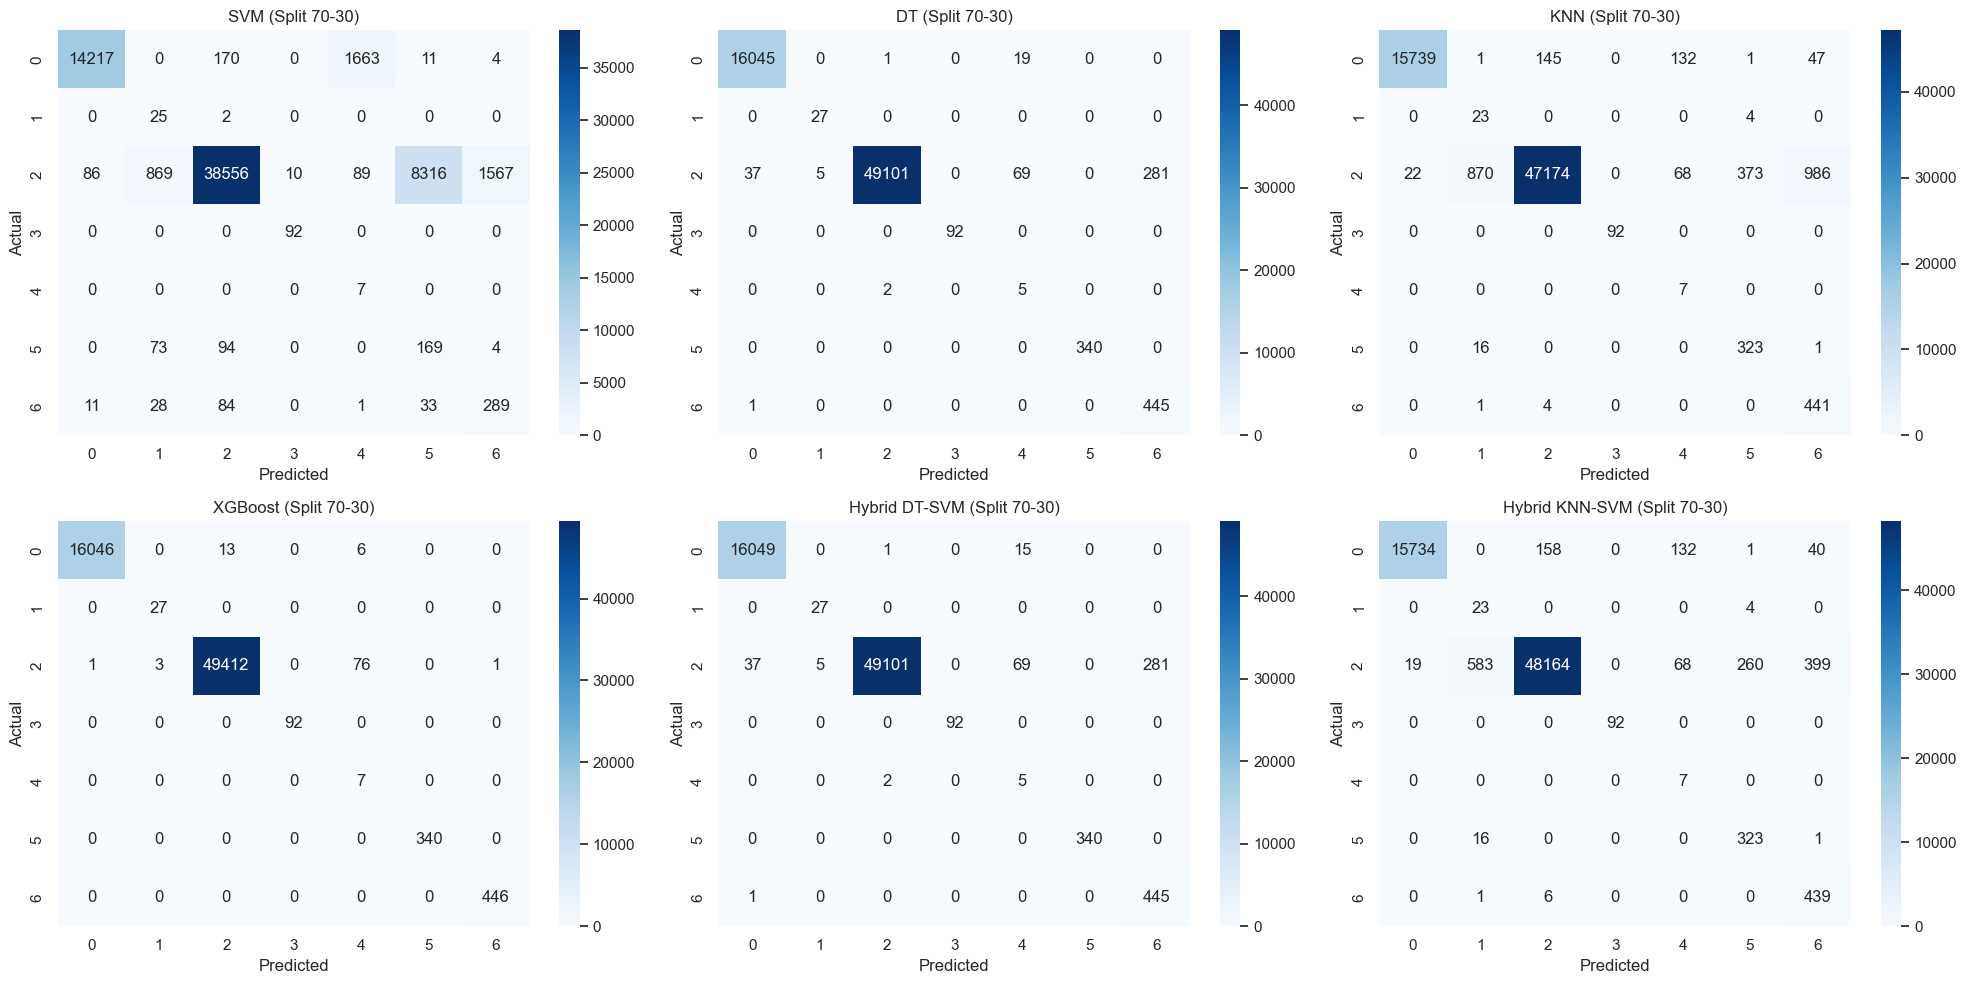

In [13]:
def plot_confusion_matrices(split_key):
    matrices = all_confusion_matrices[split_key]
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, (name, cm) in enumerate(matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f"{name} (Split {split_key})")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
    
    plt.tight_layout()
    plt.show()

# Show matrices for 70-30 split
plot_confusion_matrices("70-30")

## Model Comparison Across Metrics

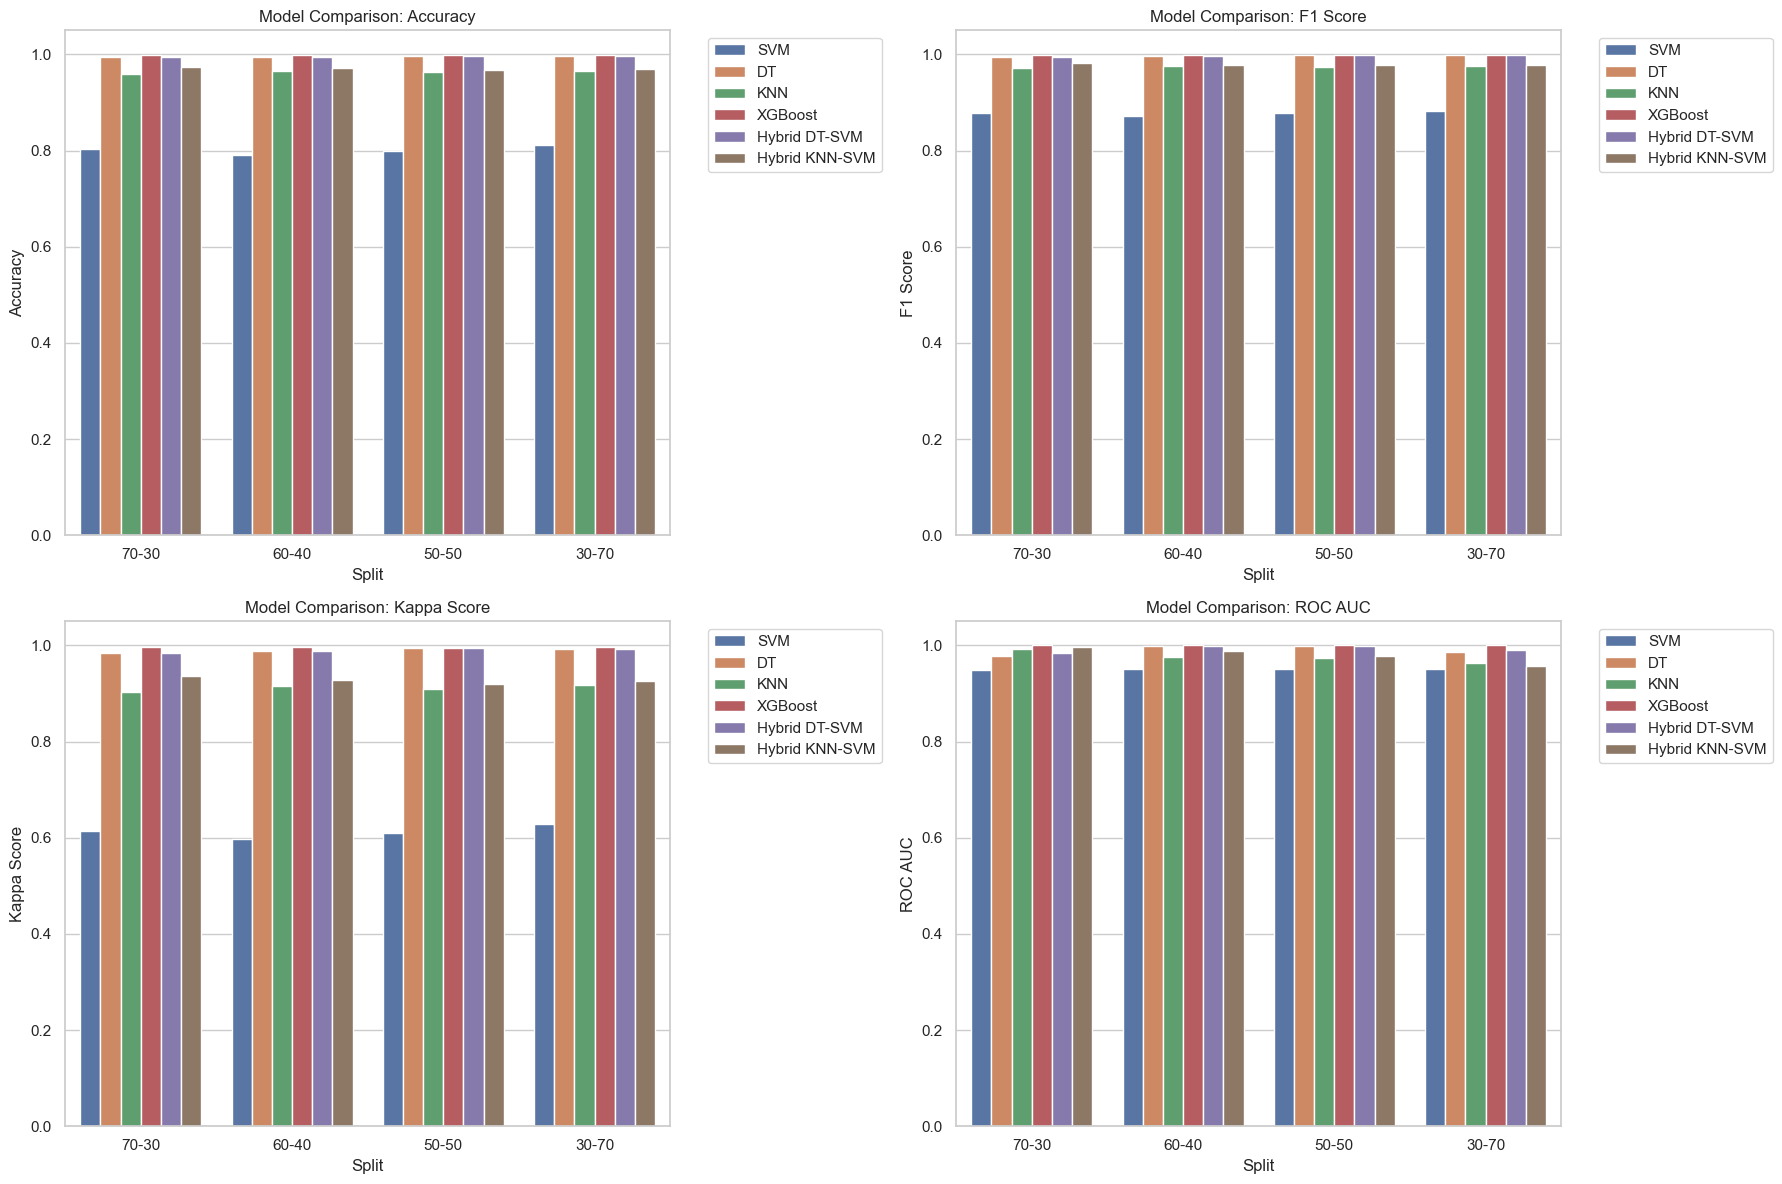

In [14]:
res_df = pd.DataFrame(results_all)

metrics = ["Accuracy", "F1 Score", "Kappa Score", "ROC AUC"]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(data=res_df, x="Split", y=metric, hue="Model", ax=axes[i])
    axes[i].set_title(f"Model Comparison: {metric}")
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
results_df = pd.DataFrame(results_all)

results_df = results_df.sort_values(["Model", "Split"])

results_df

,Split,Model,Accuracy,F1 Score,Kappa Score,ROC AUC,Time
19,30-70,DT,0.997273,0.997803,0.992982,0.985762,0.179732
13,50-50,DT,0.997500,0.998139,0.993566,0.999113,0.149356
7,60-40,DT,0.995521,0.996263,0.988491,0.998433,0.144086
1,70-30,DT,0.993757,0.994837,0.984047,0.978307,0.195915
22,30-70,Hybrid DT-SVM,0.997273,0.997803,0.992982,0.989496,0.585991
16,50-50,Hybrid DT-SVM,0.997500,0.998139,0.993566,0.999199,0.563586
10,60-40,Hybrid DT-SVM,0.995521,0.996263,0.988491,0.997987,4.313566
4,70-30,Hybrid DT-SVM,0.993817,0.994868,0.984200,0.983745,5.794196
23,30-70,Hybrid KNN-SVM,0.970231,0.977897,0.926426,0.957909,2.695691
17,50-50,Hybrid KNN-SVM,0.967639,0.976900,0.920360,0.977484,2.118813
